# Three underappreciated charts for immunization & portfolio work

1. **Dumbbell chart**: before/after change per country, ranked (a better version of the grouped bar)
2. **Fan chart**: forecast uncertainty from Monte Carlo output (a better version of the single line)
3. **ECDF plot**: compare whole distributions across groups (a better version of overlapping histograms)

All data below is **synthetic** (seeded, made-up numbers). Each section ends with a *Your turn* prompt for swapping in real data, e.g. WUENIC or IHME extracts.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(42)


## 1. Dumbbell chart: DTP3 coverage, 2019 vs 2024

**Why it works:** the eye compares *positions along a common scale*, and the line length is the change. Sorting by the change (or by the end value) makes the story obvious. Grouped bars make you compare bar heights *within* each pair and then across pairs, which is much harder.


In [2]:
countries = ["Nigeria","DRC","Ethiopia","Pakistan","Uganda","Tanzania",
             "Kenya","Bangladesh","Ghana","Mozambique","Angola","Madagascar"]
cov_2019 = rng.uniform(45, 92, len(countries)).round(0)
cov_2024 = np.clip(cov_2019 + rng.normal(0, 8, len(countries)), 30, 98).round(0)

cov = pd.DataFrame({"country": countries, "y2019": cov_2019, "y2024": cov_2024})
cov["change"] = cov["y2024"] - cov["y2019"]
cov = cov.sort_values("change").reset_index(drop=True)
cov.head()


,country,y2019,y2024,change
0,Tanzania,91.0,83.0,-8.0
1,Pakistan,78.0,71.0,-7.0
2,Mozambique,66.0,61.0,-5.0
3,Ghana,51.0,50.0,-1.0
4,Madagascar,89.0,88.0,-1.0


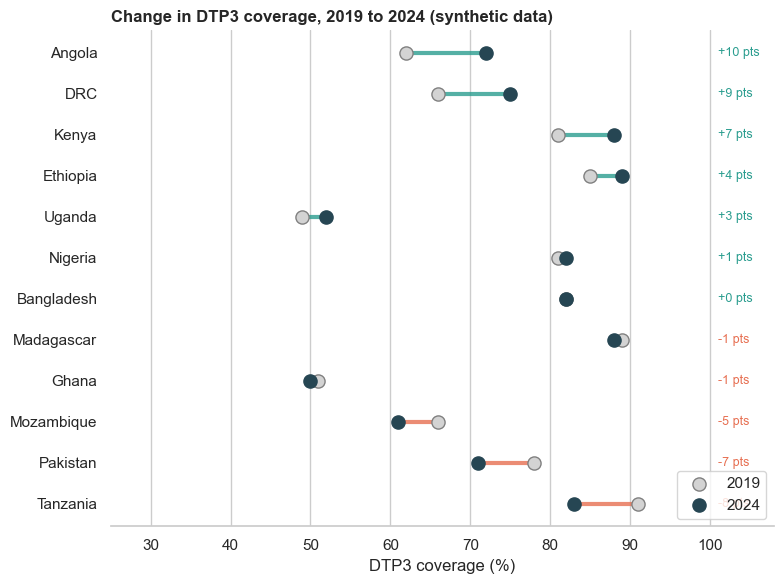

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

# color each connecting line by direction of change
line_colors = np.where(cov["change"] >= 0, "#2a9d8f", "#e76f51")
ax.hlines(y=cov.index, xmin=cov["y2019"], xmax=cov["y2024"],
          color=line_colors, linewidth=3, alpha=0.8, zorder=1)
ax.scatter(cov["y2019"], cov.index, color="lightgray", edgecolor="gray",
           s=90, zorder=2, label="2019")
ax.scatter(cov["y2024"], cov.index, color="#264653", s=90, zorder=3, label="2024")

# label the change at the right edge
for i, row in cov.iterrows():
    ax.text(101, i, f"{row.change:+.0f} pts", va="center", fontsize=9,
            color="#2a9d8f" if row.change >= 0 else "#e76f51")

ax.set_yticks(cov.index)
ax.set_yticklabels(cov["country"])
ax.set_xlim(25, 108)
ax.set_xlabel("DTP3 coverage (%)")
ax.set_title("Change in DTP3 coverage, 2019 to 2024 (synthetic data)", loc="left", fontweight="bold")
ax.legend(loc="lower right", frameon=True)
ax.grid(axis="y", visible=False)
sns.despine(left=True)
plt.tight_layout()
plt.show()


**Your turn:**
- Sort by `y2024` instead of `change`. Which story does each ordering tell?
- Add a vertical line at the 90% IA2030 target with `ax.axvline(90, ls="--")`.
- Swap in real data: reshape long WUENIC data with `df.pivot(index="country", columns="year", values="coverage")`.


## 2. Fan chart: a Monte Carlo forecast

**Why it works:** a single forecast line implies false precision. Nested quantile bands show the *shape* of uncertainty and how it widens with horizon. This is the natural output format for scenario or Monte Carlo models (e.g. vaccine demand or financing forecasts).


In [4]:
n_sims, years = 5000, np.arange(2025, 2036)
n_years = len(years)

# Synthetic "annual vaccine spend" ($M): trend growth + random shocks that accumulate
growth = rng.normal(0.04, 0.05, size=(n_sims, n_years))
paths = 800 * np.cumprod(1 + growth, axis=1)

qs = [5, 25, 50, 75, 95]
bands = pd.DataFrame(np.percentile(paths, qs, axis=0).T, index=years,
                     columns=[f"p{q}" for q in qs])
bands.round(0).head()


,p5,p25,p50,p75,p95
2025,768.0,805.0,832.0,858.0,898.0
2026,771.0,825.0,864.0,905.0,963.0
2027,783.0,848.0,897.0,950.0,1029.0
2028,795.0,873.0,932.0,995.0,1093.0
2029,811.0,899.0,966.0,1040.0,1156.0


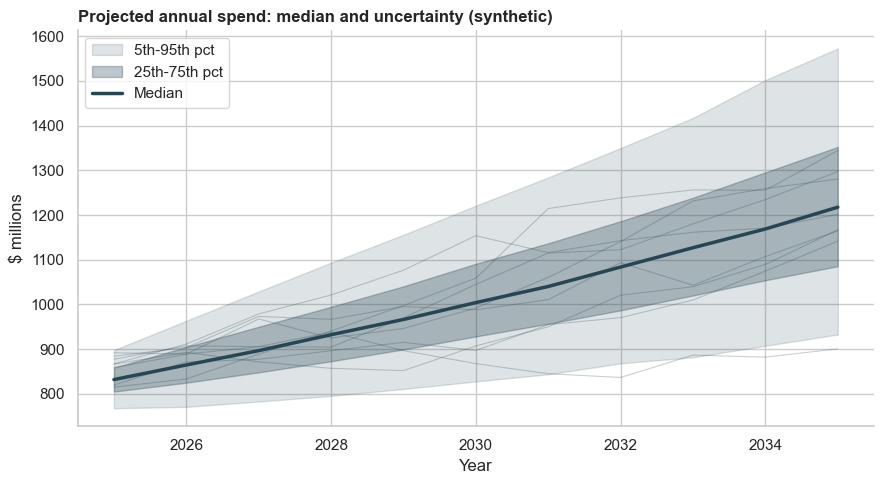

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.fill_between(bands.index, bands["p5"],  bands["p95"], color="#264653", alpha=0.15, label="5th-95th pct")
ax.fill_between(bands.index, bands["p25"], bands["p75"], color="#264653", alpha=0.30, label="25th-75th pct")
ax.plot(bands.index, bands["p50"], color="#264653", linewidth=2.5, label="Median")

# a few individual simulated paths to show what a band is made of
for p in paths[:8]:
    ax.plot(years, p, color="#264653", alpha=0.25, linewidth=0.8)

ax.set_title("Projected annual spend: median and uncertainty (synthetic)", loc="left", fontweight="bold")
ax.set_ylabel("$ millions")
ax.set_xlabel("Year")
ax.legend(loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()


**Your turn:**
- Change the growth volatility from `0.05` to `0.02` and `0.10`. How does the fan shape change?
- Add a horizontal budget line (`ax.axhline(1100, color="red", ls="--")`) and compute `(paths[:, -1] > 1100).mean()`, the probability of exceeding it in 2035.
- Try 10/90 bands instead of 5/95, and consider which your audience would find more intuitive.


## 3. ECDF plot: comparing distributions across groups

**Why it works:** histograms depend on bin choices, and overlapping ones get muddy fast. An empirical CDF has no bins, shows every data point, and lets you read off percentiles directly ("what share of districts are below 80% coverage?"). Gaps between curves show *where* in the distribution groups differ, not only at the mean.

Here: district-level coverage in three synthetic regions.


In [6]:
regions = {"Region A": (78, 10), "Region B": (70, 18), "Region C": (85, 7)}
districts = pd.concat([
    pd.DataFrame({"region": r,
                  "coverage": np.clip(rng.normal(mu, sd, 150), 5, 99)})
    for r, (mu, sd) in regions.items()
], ignore_index=True)

districts.groupby("region")["coverage"].describe().round(1)


,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
Region A,150.0,77.3,11.0,46.6,70.5,77.2,84.8,99.0
Region B,150.0,69.6,16.8,11.0,57.2,70.9,83.5,99.0
Region C,150.0,85.4,6.6,70.9,80.7,85.9,90.3,99.0


Region A: 58% of districts below 80% coverage
Region B: 70% of districts below 80% coverage
Region C: 24% of districts below 80% coverage


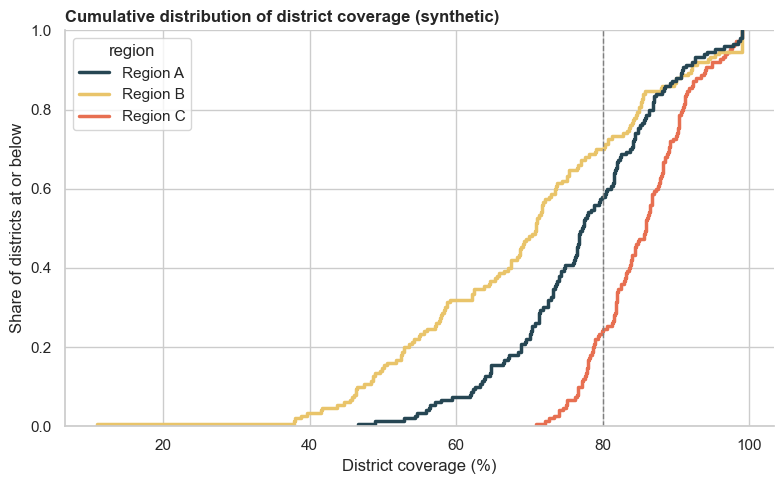

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.ecdfplot(data=districts, x="coverage", hue="region", linewidth=2.5, ax=ax,
             palette=["#264653", "#e9c46a", "#e76f51"])

# reference line: share of districts below 80% coverage
ax.axvline(80, color="gray", ls="--", linewidth=1)
for r, g in districts.groupby("region"):
    share = (g["coverage"] < 80).mean()
    print(f"{r}: {share:.0%} of districts below 80% coverage")

ax.set_xlabel("District coverage (%)")
ax.set_ylabel("Share of districts at or below")
ax.set_title("Cumulative distribution of district coverage (synthetic)", loc="left", fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()


**Your turn:**
- Add `complementary=True` to `ecdfplot` to flip it to "share of districts *above* x" (often a more natural framing for coverage targets).
- Add `rug=True` via `sns.rugplot(data=districts, x="coverage", hue="region", ax=ax)` to see the raw points.
- Compare with `sns.histplot(..., element="step")`. Which one lets you spot Region B's long left tail faster?


## Bonus ideas
- **`sns.clustermap`** on a scoring matrix (investments x criteria) to reveal natural groupings
- **Slope chart** (a two-point dumbbell turned sideways) for rank changes between two years
- **`sns.pointplot` with bootstrapped CIs** for group comparisons that respect uncertainty
